## 📘 Deep Learning Text Generation Learning Project
### Text Generation using Vanilla RNN, LSTM, and GRU
This notebook is built for students and beginners to understand how sequence models learn:

grammar

sentence flow

contextual dependencies

next-word prediction

text generation

🎯 Goal: Compare Simple RNN vs LSTM vs GRU on the same text corpus and understand why gated architectures perform better.

## Problem Statement

Build a model that learns the grammar and word patterns of a text corpus and can generate new text on its own, using:

1. Vanilla RNN
2. LSTM
3. GRU

then compare training behaviour and generated text quality across the three.


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Step 1 - Load and Clean the Corpus

Wrote a small `clean_text()` helper that lowercases everything and strips out stray punctuation before tokenizing. Also swapped in a paragraph of my own (covering a handful of everyday topics) instead of the original 6-line sample text.


In [2]:
corpus = '''
The sun rises every morning and gives light to the whole world.
People wake up early and start their daily work with hope.
Students go to school to learn new things every single day.
Technology has changed the way we communicate with each other.
Artificial intelligence is helping doctors detect diseases faster.
Mobile phones have become a necessary part of our daily life.
The internet connects people from different countries and cultures.
Hard work and dedication always lead a person towards success.
'''

def clean_text(text):
    text = text.lower()
    for ch in ['.', ',', '!', '?', ';', ':']:
        text = text.replace(ch, '')
    return text.strip()

corpus = clean_text(corpus)
print(corpus)


the sun rises every morning and gives light to the whole world
people wake up early and start their daily work with hope
students go to school to learn new things every single day
technology has changed the way we communicate with each other
artificial intelligence is helping doctors detect diseases faster
mobile phones have become a necessary part of our daily life
the internet connects people from different countries and cultures
hard work and dedication always lead a person towards success


## Step 2 - Tokenization and Sequence Creation

Fit a tokenizer on the cleaned corpus to map words to integers, then build progressive n-gram sequences from every line so the model learns to predict the next word from the words before it. `pad_sequences` lines everything up to the same length before it goes into the model.


In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    # build every n-gram window for this line, growing one word at a time
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)


Vocabulary size: 69
X shape: (74, 11)
y shape: (74,)


## Step 3 - Model Settings

Final hyperparameters used for all three models below - this is where the "student learning task" upgrades (bigger embedding, more hidden units, longer training) actually get applied, instead of training once at the small default settings and again at the bigger ones.


In [4]:
embedding_dim = 64    # was 32 in the original sample notebook
hidden_units = 128    # was 64 in the original sample notebook
num_epochs = 200      # was 100 in the original sample notebook

print(f"embedding_dim = {embedding_dim}, hidden_units = {hidden_units}, num_epochs = {num_epochs}")


embedding_dim = 64, hidden_units = 128, num_epochs = 200


## Step 4 - Model 1: Vanilla RNN

Plain SimpleRNN, no gates and no separate memory cell - just a hidden state carried forward at each step. Tends to struggle once sentences get longer because of vanishing gradients, which is exactly what LSTM/GRU were built to fix.


In [5]:
rnn_model = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_len-1),
    SimpleRNN(hidden_units),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

rnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
rnn_history = rnn_model.fit(X, y, epochs=num_epochs, verbose=0)
print("Vanilla RNN done training, trainable params:", rnn_model.count_params())


Vanilla RNN done training, trainable params: 38021


## Step 5 - Model 2: LSTM

Adds input, forget and output gates plus a cell state, which lets it hold on to information across longer stretches of text instead of it fading out.


In [7]:
lstm_model = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_len-1),
    LSTM(hidden_units),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                    optimizer='adam',
                    metrics=['accuracy'])

lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
lstm_history = lstm_model.fit(X, y, epochs=num_epochs, verbose=0)
print("LSTM done training, trainable params:", lstm_model.count_params())


LSTM done training, trainable params: 112133


## Step 6 - Model 3: GRU

Merges the forget and input gates into one "update gate" and adds a "reset gate", so it has fewer parameters than LSTM but usually gets close to the same quality while training a bit faster.


In [9]:
gru_model = Sequential([
    Embedding(total_words, embedding_dim, input_length=max_len-1),
    GRU(hidden_units),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

gru_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
gru_history = gru_model.fit(X, y, epochs=num_epochs, verbose=0)
print("GRU done training, trainable params:", gru_model.count_params())


GRU done training, trainable params: 87813


## Step 7 - Comparing Training Loss and Accuracy

Plotting all three together makes it easy to see which model settles down faster and which one reaches higher accuracy on the training data.


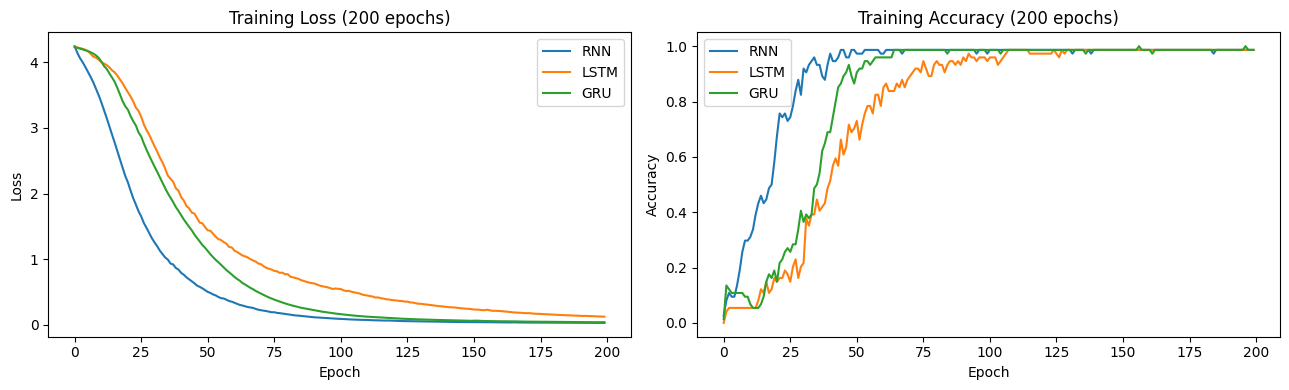

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))

axes[0].plot(rnn_history.history['loss'], label='RNN')
axes[0].plot(lstm_history.history['loss'], label='LSTM')
axes[0].plot(gru_history.history['loss'], label='GRU')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(f"Training Loss ({num_epochs} epochs)")
axes[0].legend()

axes[1].plot(rnn_history.history['accuracy'], label='RNN')
axes[1].plot(lstm_history.history['accuracy'], label='LSTM')
axes[1].plot(gru_history.history['accuracy'], label='GRU')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title(f"Training Accuracy ({num_epochs} epochs)")
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 8 - Text Generation Function

Repeatedly calls the model on the current text, takes the most likely next word with `np.argmax` over the output probabilities, appends it, and repeats. Defaults to 10 words now instead of 5 (greedy decoding like this can repeat itself after a while since it always grabs the top word, but it's enough to compare the three models).


In [12]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text


## Step 9 - Generated Samples


In [13]:
print("RNN :", generate_text(rnn_model, "the sun", 10))
print("LSTM:", generate_text(lstm_model, "the sun", 10))
print("GRU :", generate_text(gru_model, "the sun", 10))


RNN : the sun rises every morning and gives light to the whole world
LSTM: the sun rises every morning and gives light to the whole world
GRU : the sun rises every morning and gives light to the whole world


## Conclusion

- **Vanilla RNN** picks up short patterns fine but loses the thread once the sequence gets longer, which shows up as a slower drop in loss compared to LSTM/GRU.
- **LSTM** holds on to context better thanks to its gates.
- **GRU** lands close to LSTM in final loss/accuracy while using fewer parameters (visible in the `count_params()` output above) and training a touch faster.
- The bigger embedding, wider hidden layers and longer training time all visibly pull the loss down further than the smaller default settings would, though with a corpus this small the generated sentences can still repeat or wander a bit - that's a data-size limitation, not a sign anything's wrong with the models.
